# The Arakawa C-Grid

Every somax model discretises its fields on a **staggered** Arakawa C-grid, supplied by [finitevolX](https://github.com/jejjohnson/finitevolX). Staggering is not an implementation detail — it is the choice that makes the discrete operators mimic the continuous ones (a discrete gradient that lands exactly where the next operator needs it, a divergence that is genuinely the adjoint of the gradient). This chapter shows where each field lives, how ghost cells frame the physical interior, and why the layout matters {cite}`arakawa1977computational,durran2010numerical`.

**What you will learn**

- The four stagger positions (T, U, V, X) and the half-index convention that places them
- How finitevolX frames the interior with a one-cell ghost halo
- How to construct a grid and create correctly-shaped staggered fields

## Why stagger?

Consider the rotating shallow-water system, the prototype for the ocean models in this book {cite}`vallis2017atmospheric`. Mass conservation couples the layer thickness $h$ to the divergence of the transport,

```{math}
:label: cgrid-continuity
\partial_t h + \nabla\cdot(h\,\mathbf{u}) = 0,
```

while the momentum balance couples the velocity $\mathbf{u}=(u,v)$ to the pressure gradient,

```{math}
:label: cgrid-momentum
\partial_t \mathbf{u} + (f\,\hat{\mathbf{z}}\times\mathbf{u}) = -g\,\nabla h .
```

On a **collocated** grid (all variables at the cell centre), the pressure gradient $\nabla h$ in {eq}`cgrid-momentum` needs a centred two-cell stencil, which is blind to the $2\Delta x$ checkerboard mode — pressure and velocity decouple and spurious grid-scale noise grows. The C-grid cure is to place $u$ and $v$ on the **cell faces**, half a cell from the pressure point, so the gradient in {eq}`cgrid-momentum` and the divergence in {eq}`cgrid-continuity` both become compact one-cell differences that see every mode {cite}`arakawa1977computational`.

## The four stagger positions

A 2-D C-grid cell carries its variables at four distinct locations, named by the somax/finitevolX convention in {numref}`cgrid-stagger-table`. Writing the cell index as $[j, i]$ (row $j$, column $i$) and the cell spacing as $(\Delta x, \Delta y)$, the half-index offsets are:

```{list-table} Stagger positions on the Arakawa C-grid. The index $[j,i]$ labels the south-west corner of the stencil neighbourhood (the "same-index" rule).
:header-rows: 1
:label: cgrid-stagger-table

* - Symbol
  - Name
  - Location
  - Position of $[j,i]$
  - Typical field
* - `T`
  - cell centre
  - tracer point
  - $(i\,\Delta x,\; j\,\Delta y)$
  - thickness $h$, pressure
* - `U`
  - east face
  - x-velocity point
  - $((i+\tfrac12)\,\Delta x,\; j\,\Delta y)$
  - zonal velocity $u$
* - `V`
  - north face
  - y-velocity point
  - $(i\,\Delta x,\; (j+\tfrac12)\,\Delta y)$
  - meridional velocity $v$
* - `X`
  - north-east corner
  - vorticity point
  - $((i+\tfrac12)\,\Delta x,\; (j+\tfrac12)\,\Delta y)$
  - vorticity $\zeta$, PV $q$
```

The placement is exactly what the equations want: $u$ sits where $\partial_x h$ is naturally defined (between two T-points), and the vorticity $\zeta = \partial_x v - \partial_y u$ lands cleanly at the corner where the circulation around a cell is measured.

## Constructing a grid

finitevolX exposes the C-grid through `CartesianGrid2D`. The `from_interior` factory is the idiomatic constructor: you give it the number of *physical* (interior) cells and the domain size, and it computes the spacing and adds the ghost halo.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import finitevolx as fvx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,finitevolx,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


In [3]:
nx_interior = ny_interior = 16
grid = fvx.CartesianGrid2D.from_interior(
    nx_interior=nx_interior, ny_interior=ny_interior, Lx=1.0, Ly=1.0
)
print(f"interior cells : {nx_interior} x {ny_interior}")
print(
    f"full grid      : Nx={grid.Nx} x Ny={grid.Ny}  (interior + 1 ghost cell per side)"
)
print(f"spacing        : dx={grid.dx:.4f}, dy={grid.dy:.4f}")

interior cells : 16 x 16
full grid      : Nx=18 x Ny=18  (interior + 1 ghost cell per side)
spacing        : dx=0.0625, dy=0.0625


## Ghost cells frame the interior

finitevolX surrounds the $n_x \times n_y$ physical cells with a **one-cell ghost halo**, so the stored arrays are $(n_y+2)\times(n_x+2)$. The ghost cells hold the boundary-condition values (next chapter); every diagnostic and conserved integral in somax is taken over the *interior* slice `[1:-1, 1:-1]` to exclude them. All four stagger types share this same full shape — only their physical *interpretation* differs.

In [4]:
Ny, Nx = grid.Ny, grid.Nx
h = jnp.zeros((Ny, Nx))  # T-point: thickness / pressure
u = jnp.zeros((Ny, Nx))  # U-point: zonal velocity
v = jnp.zeros((Ny, Nx))  # V-point: meridional velocity
q = jnp.zeros((Ny, Nx))  # X-point: vorticity / PV

interior = (slice(1, -1), slice(1, -1))
print(f"stored field shape   : {h.shape}")
print(
    f"interior field shape : {h[interior].shape}  (the {nx_interior}x{ny_interior} physical cells)"
)

stored field shape   : (18, 18)
interior field shape : (16, 16)  (the 16x16 physical cells)


## Visualising the stagger

{numref}`cgrid-stagger-fig` overlays the four stagger positions for a single cell. The tracer point `T` anchors the cell; `U`/`V` sit on the east/north faces half a cell away; the vorticity point `X` sits at the north-east corner. This is the geometry that makes the discrete gradient, divergence, and curl land exactly where the next operator consumes them (next chapter).

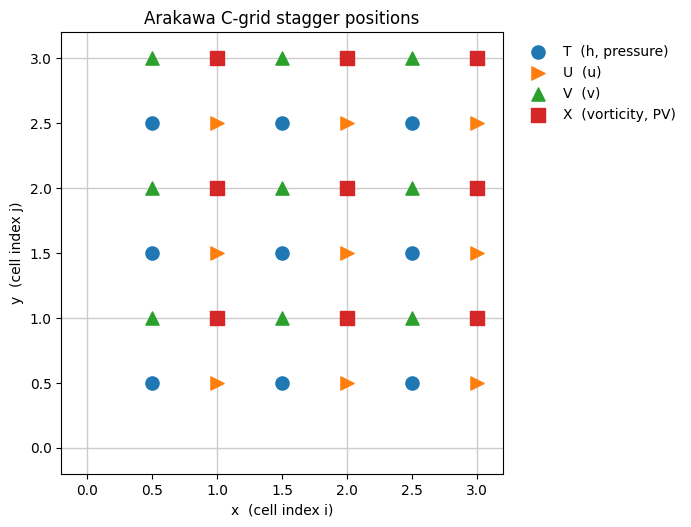

In [5]:
# The notebook executes with cwd = content/tutorials/, and figures are
# referenced as ../images/<name>/ — i.e. content/images/<name>/.
IMG_DIR = Path.cwd().parent / "images" / "arakawa_cgrid"
IMG_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 7))
# Draw a 3x3 block of cells.
for k in range(4):
    ax.axhline(k, color="0.8", lw=1)
    ax.axvline(k, color="0.8", lw=1)
# Stagger markers for the cells.
tc, uc, vc, xc = [], [], [], []
for j in range(3):
    for i in range(3):
        tc.append((i + 0.5, j + 0.5))  # centre
        uc.append((i + 1.0, j + 0.5))  # east face
        vc.append((i + 0.5, j + 1.0))  # north face
        xc.append((i + 1.0, j + 1.0))  # NE corner
for pts, marker, label, color in [
    (tc, "o", "T  (h, pressure)", "C0"),
    (uc, ">", "U  (u)", "C1"),
    (vc, "^", "V  (v)", "C2"),
    (xc, "s", "X  (vorticity, PV)", "C3"),
]:
    arr = np.array(pts)
    ax.scatter(
        arr[:, 0], arr[:, 1], marker=marker, s=90, color=color, label=label, zorder=3
    )
ax.set(
    xlim=(-0.2, 3.2),
    ylim=(-0.2, 3.2),
    xlabel="x  (cell index i)",
    ylabel="y  (cell index j)",
    title="Arakawa C-grid stagger positions",
    aspect="equal",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
fig.tight_layout()
fig.savefig(IMG_DIR / "stagger_positions.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/arakawa_cgrid/stagger_positions.png
:label: cgrid-stagger-fig
:width: 80%

The four Arakawa C-grid stagger positions over a 3×3 block of cells. Tracer
quantities (`T`) sit at cell centres; velocities (`U`, `V`) on the east and
north faces; vorticity / potential vorticity (`X`) at the north-east corners.
```

## Summary

- somax fields live on a staggered Arakawa C-grid: `T` (centre), `U`/`V` (faces), `X` (corner) — see {numref}`cgrid-stagger-table` and {numref}`cgrid-stagger-fig`.
- Staggering makes the pressure gradient in {eq}`cgrid-momentum` and the divergence in {eq}`cgrid-continuity` compact, mode-aware operators — the original motivation of {cite}`arakawa1977computational`.
- `CartesianGrid2D.from_interior(...)` builds the grid; the stored arrays carry a one-cell ghost halo, and diagnostics use the `[1:-1, 1:-1]` interior slice.

The next chapter, [discrete operators](operators.ipynb), shows how the staggering lets `Difference2D` map fields between these positions to build gradients, divergences, and the vorticity.

## References

```{bibliography}
:filter: docname in docnames
```